# BirdCLEF+ 2026: **Perch v2 Embedding Probes**

- **Description:** This project utilizes Google's **Perch v2** (**vocalization-classifier**) as a **frozen backbone** to extract **1536-dimensional embeddings** from bird recordings. We implement a custom **PyTorch Multi-Layer Perceptron (MLP) "Probe"** to **classify** these high-level features into specific bird species.
- **Dataset:** **BirdCLEF 2026 Kaggle Dataset**
- **Objective:** Build a **robust inference pipeline** capable of processing hidden test soundscapes and achieving a competitive **F1-score/CMAP**.

# 1. ENVIRONMENT SETUP & CONFIGURATION

## 1.1 Library Imports

We need both **TensorFlow** (to run the **Perch backbone**) and **PyTorch** (to run our **classification head**). We also include **librosa** for **audio handling** and **timm** for potential **backbone swaps**.

In [1]:
!pip install -q --upgrade tensorflow

In [2]:
import os
import gc
import json
import time
import warnings
from pathlib import Path

# Data & Audio
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
from tqdm.auto import tqdm

# Deep Learning Frameworks
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import tensorflow as tf

warnings.filterwarnings('ignore')
# Enable TF numpy behavior for easier array manipulation
tf.experimental.numpy.experimental_enable_numpy_behavior()

2026-04-03 23:44:34.462380: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775259874.906377      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775259875.020345      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775259876.076774      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775259876.076815      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775259876.076818      24 computation_placer.cc:177] computation placer alr

## 1.2 Global Constants (CFG)

We define our **hyperparameters** and **paths** here. Note the **1536 embedding size**—this is fixed by the **Perch v2 architecture**.

In [3]:
class CFG:
    # --- Reproducibility ---
    RANDOM_SEED = 42
    
    # --- Path Configuration ---
    INPUT_DIR = Path("/kaggle/input/competitions/birdclef-2026")
    # Path to the Google Perch v2 model on Kaggle
    PERCH_PATH = "/kaggle/input/models/google/bird-vocalization-classifier/tensorflow2/perch_v2/2" 
    
    # --- Audio Specs ---
    TARGET_SR = 32000      # Perch requires 32kHz
    DURATION = 5           # Windows of 5 seconds
    CHUNK_SAMPLES = TARGET_SR * DURATION 
    
    # --- Model Specs ---
    MODEL_NAME = "perch_v2_mlp_probe"
    EMBEDDING_SIZE = 1536  # Fixed output size of Perch v2
    NUM_CLASSES = 234      # Total number of bird species in this competition
    
    # --- Training Hyperparameters ---
    BATCH_SIZE = 64
    LR = 1e-3
    EPOCHS = 25
    THRESHOLD = 0.05       # Prediction probability threshold

## 1.3 Hardware Accelerator

**Perch v2 (CPU version)** runs very efficiently on **Kaggle's multi-core CPUs**. We will configure **PyTorch** to use the **GPU** if available for the **"Probe" training**.

In [4]:
# Set Seed
torch.manual_seed(CFG.RANDOM_SEED)
np.random.seed(CFG.RANDOM_SEED)

# Device Logic
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")
print(f"TensorFlow version: {tf.__version__}")
print(f"PyTorch version: {torch.__version__}")

Device: cuda
TensorFlow version: 2.19.0
PyTorch version: 2.10.0+cu128


# 2. DATA ENGINEERING & PREPROCESSING

## 2.1 Data Ingestion

We load the primary metadata provided by **Kaggle**. This file contains the mapping between **audio files** and **bird species** (**primary_label**).

In [5]:
# List the contents of the dataset directory
print(f"Contents of {CFG.INPUT_DIR}:")
for item in os.listdir(CFG.INPUT_DIR):
    print(f"- {item}")

Contents of /kaggle/input/competitions/birdclef-2026:
- sample_submission.csv
- taxonomy.csv
- train_audio
- train_soundscapes_labels.csv
- train_soundscapes
- train.csv
- recording_location.txt
- test_soundscapes


In [6]:
# Load the main training manifest
train_df = pd.read_csv(CFG.INPUT_DIR / "train.csv")

# According to the data description, files are flat in the train_audio directory
# Filenames already include the collection prefix (e.g., XC or iNat)
train_df['file_path'] = train_df['filename'].apply(
    lambda x: CFG.INPUT_DIR / "train_audio" / x
)

# Quick look at the structure
print(f"Shape: {train_df.shape}")
display(train_df.info())
display(train_df.head(10))

Shape: (35549, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35549 entries, 0 to 35548
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   primary_label     35549 non-null  object 
 1   secondary_labels  35549 non-null  object 
 2   type              35549 non-null  object 
 3   latitude          35549 non-null  float64
 4   longitude         35549 non-null  float64
 5   scientific_name   35549 non-null  object 
 6   common_name       35549 non-null  object 
 7   class_name        35549 non-null  object 
 8   inat_taxon_id     35549 non-null  int64  
 9   author            35549 non-null  object 
 10  license           35549 non-null  object 
 11  rating            35549 non-null  float64
 12  url               35549 non-null  object 
 13  filename          35549 non-null  object 
 14  collection        35549 non-null  object 
 15  file_path         35549 non-null  object 
dtypes: float64(3), int64(

None

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection,file_path
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat,/kaggle/input/competitions/birdclef-2026/train...
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat,/kaggle/input/competitions/birdclef-2026/train...
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat,/kaggle/input/competitions/birdclef-2026/train...
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat,/kaggle/input/competitions/birdclef-2026/train...
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat,/kaggle/input/competitions/birdclef-2026/train...
5,1161364,[],[],-22.0843,-47.7327,Guyalna cuta,Guyalna cuta,Insecta,1161364,Carlos Otávio Gussoni,cc-by-nc,0.0,https://static.inaturalist.org/sounds/868369.w...,1161364/iNat868369.ogg,iNat,/kaggle/input/competitions/birdclef-2026/train...
6,1161364,[],[],-20.9848,-43.7609,Guyalna cuta,Guyalna cuta,Insecta,1161364,Pedro Cavalcante,cc-by-nc,0.0,https://static.inaturalist.org/sounds/842139.w...,1161364/iNat842139.ogg,iNat,/kaggle/input/competitions/birdclef-2026/train...
7,1161364,[],[],-19.9674,-43.9895,Guyalna cuta,Guyalna cuta,Insecta,1161364,Pedro Cavalcante,cc-by-nc,0.0,https://static.inaturalist.org/sounds/840159.m...,1161364/iNat840159.ogg,iNat,/kaggle/input/competitions/birdclef-2026/train...
8,1161364,[],[],-19.8713,-43.9607,Guyalna cuta,Guyalna cuta,Insecta,1161364,Alexandre S. Michelotto,cc0,0.0,https://static.inaturalist.org/sounds/1264238....,1161364/iNat1264238.ogg,iNat,/kaggle/input/competitions/birdclef-2026/train...
9,1161364,[],[],-18.8358,-40.7354,Guyalna cuta,Guyalna cuta,Insecta,1161364,Vitor C. Dias Gonçalves,cc-by-nc,0.0,https://static.inaturalist.org/sounds/869958.m...,1161364/iNat869958.ogg,iNat,/kaggle/input/competitions/birdclef-2026/train...


In [7]:
# Load taxonomy to get the definitive list of 234 classes
taxonomy_df = pd.read_csv(CFG.INPUT_DIR / "taxonomy.csv")

# These 234 primary_labels are our target columns for submission
TARGET_COLUMNS = sorted(taxonomy_df['primary_label'].unique().tolist())
CFG.NUM_CLASSES = len(TARGET_COLUMNS)

print(f"Target Classes: {CFG.NUM_CLASSES}")
print(f"Example Classes: {TARGET_COLUMNS[:5]}")

display(taxonomy_df.info())
display(taxonomy_df.head(10))

Target Classes: 234
Example Classes: ['1161364', '116570', '1176823', '1491113', '1595929']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   primary_label    234 non-null    object
 1   inat_taxon_id    234 non-null    int64 
 2   scientific_name  234 non-null    object
 3   common_name      234 non-null    object
 4   class_name       234 non-null    object
dtypes: int64(1), object(4)
memory usage: 9.3+ KB


None

,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1161364,1161364,Guyalna cuta,Guyalna cuta,Insecta
1,116570,116570,Caiman yacare,Southern Spectacled Caiman,Reptilia
2,1176823,1176823,Leptodactylus luctator,Wrestler Frog,Amphibia
3,1491113,1491113,Adenomera guarani,Guaraní leaf-litter frog,Amphibia
4,1595929,1595929,Lysapsus limellum,Uruguay Harlequin Frog,Amphibia
5,209233,209233,Equus caballus,Feral Horse,Mammalia
6,22930,22930,Leptodactylus syphax,Basin White-lipped Frog,Amphibia
7,22956,22956,Leptodactylus mystacinus,Mustached Frog,Amphibia
8,22961,22961,Leptodactylus podicipinus,Pointedbelly Frog,Amphibia
9,22967,22967,Leptodactylus elenae,Marbled White-lipped Frog,Amphibia


In [8]:
# Load soundscape labels for validation or additional training
ss_labels_df = pd.read_csv(CFG.INPUT_DIR / "train_soundscapes_labels.csv")

# Map filenames to their full paths in the train_soundscapes folder
ss_labels_df['file_path'] = ss_labels_df['filename'].apply(
    lambda x: CFG.INPUT_DIR / "train_soundscapes" / x
)

print(f"Labeled Soundscape Segments: {ss_labels_df.shape[0]}")

display(ss_labels_df.info())
display(ss_labels_df.head(10))

Labeled Soundscape Segments: 1478
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1478 entries, 0 to 1477
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   filename       1478 non-null   object
 1   start          1478 non-null   object
 2   end            1478 non-null   object
 3   primary_label  1478 non-null   object
 4   file_path      1478 non-null   object
dtypes: object(5)
memory usage: 57.9+ KB


None

,filename,start,end,primary_label,file_path
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380,/kaggle/input/competitions/birdclef-2026/train...
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380,/kaggle/input/competitions/birdclef-2026/train...
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380,/kaggle/input/competitions/birdclef-2026/train...
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380,/kaggle/input/competitions/birdclef-2026/train...
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380,/kaggle/input/competitions/birdclef-2026/train...
5,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:25,00:00:30,22961;23158;24321;517063;65380,/kaggle/input/competitions/birdclef-2026/train...
6,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:30,00:00:35,22961;23158;24321;517063;65380,/kaggle/input/competitions/birdclef-2026/train...
7,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:35,00:00:40,22961;23158;24321;517063;65380,/kaggle/input/competitions/birdclef-2026/train...
8,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:40,00:00:45,22961;23158;24321;65380,/kaggle/input/competitions/birdclef-2026/train...
9,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:45,00:00:50,22961;23158;24321;517063;65380,/kaggle/input/competitions/birdclef-2026/train...


## 2.2 Exploratory Data Analysis (EDA)

With the **metadata ingested** and the **target classes defined**, the focus shifts to analyzing the **distribution**, **quality**, and **temporal characteristics** of the **acoustic data**. This stage is critical for identifying potential biases that could affect the performance of the **Perch v2 embeddings**.

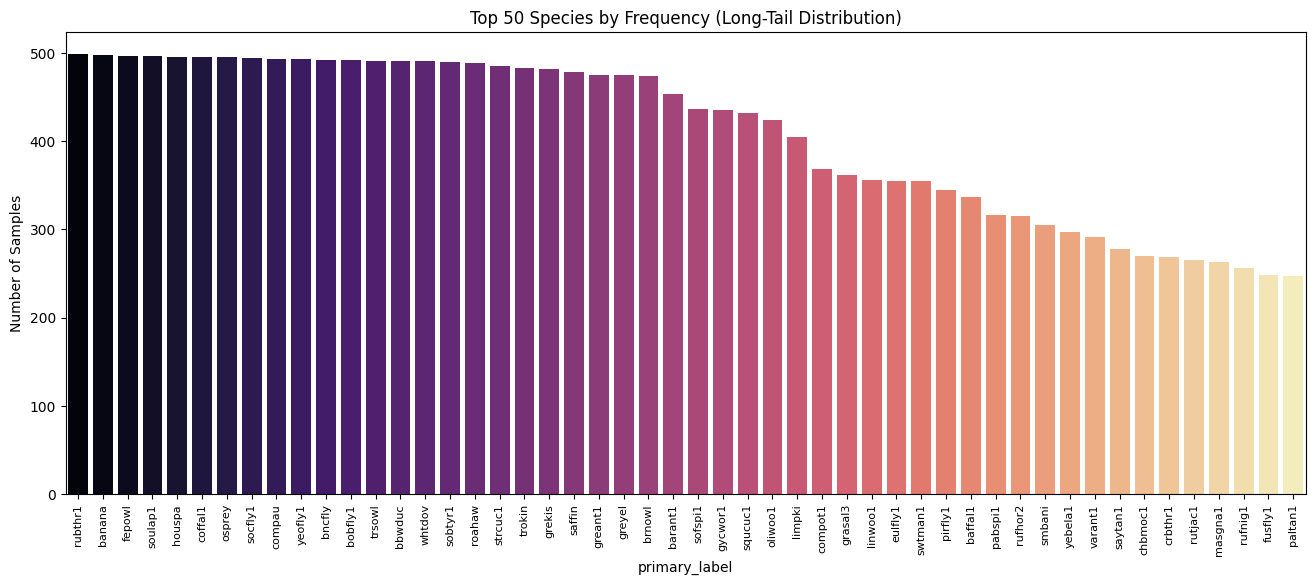

Mean samples per class: 172.57
Median samples per class: 125.00
Classes with < 10 samples: 25


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate counts per species
species_counts = train_df['primary_label'].value_counts()

plt.figure(figsize=(16, 6))
sns.barplot(x=species_counts.index[:50], y=species_counts.values[:50], palette='magma')
plt.xticks(rotation=90, fontsize=8)
plt.title("Top 50 Species by Frequency (Long-Tail Distribution)")
plt.ylabel("Number of Samples")
plt.show()

print(f"Mean samples per class: {species_counts.mean():.2f}")
print(f"Median samples per class: {species_counts.median():.2f}")
print(f"Classes with < 10 samples: {(species_counts < 10).sum()}")

In [10]:
species_counts

primary_label
rubthr1    499
banana     498
fepowl     497
soulap1    497
houspa     496
          ... 
209233       2
516975       1
23724        1
116570       1
23150        1
Name: count, Length: 206, dtype: int64

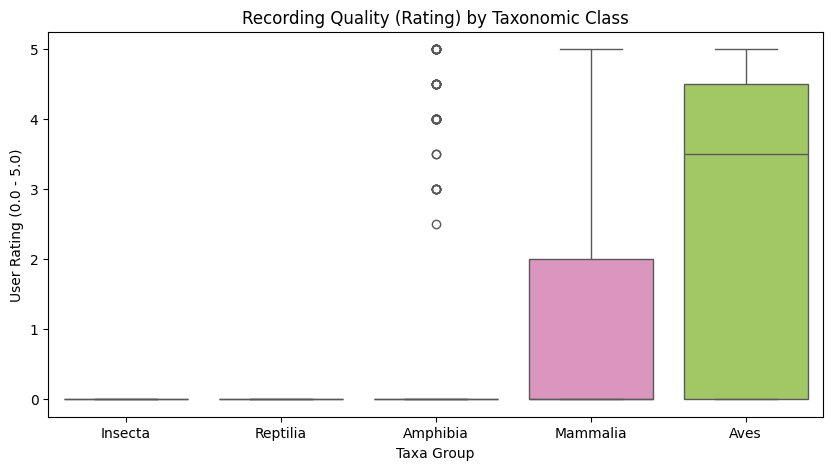

In [11]:
# Grouping by class_name (Aves, Insecta, etc.) to see quality per taxa
plt.figure(figsize=(10, 5))
sns.boxplot(data=train_df, x='class_name', y='rating', palette='Set2')
plt.title("Recording Quality (Rating) by Taxonomic Class")
plt.ylabel("User Rating (0.0 - 5.0)")
plt.xlabel("Taxa Group")
plt.show()

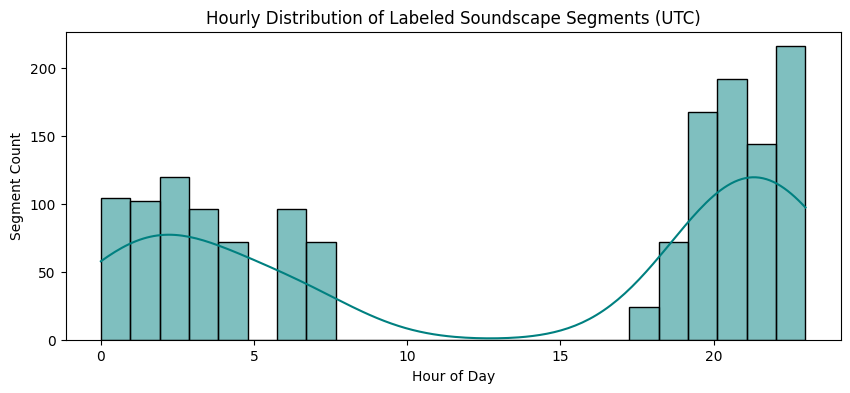

In [12]:
# Extract hour from soundscape filenames using regex
# Filename format: BC2026_Train_0039_S22_20211231_201500.ogg
import re

def extract_hour(filename):
    match = re.search(r'_(\d{6})\.ogg', filename)
    if match:
        return int(match.group(1)[:2])
    return None

ss_labels_df['hour'] = ss_labels_df['filename'].apply(extract_hour)

plt.figure(figsize=(10, 4))
sns.histplot(ss_labels_df['hour'], bins=24, kde=True, color='teal')
plt.title("Hourly Distribution of Labeled Soundscape Segments (UTC)")
plt.xlabel("Hour of Day")
plt.ylabel("Segment Count")
plt.show()

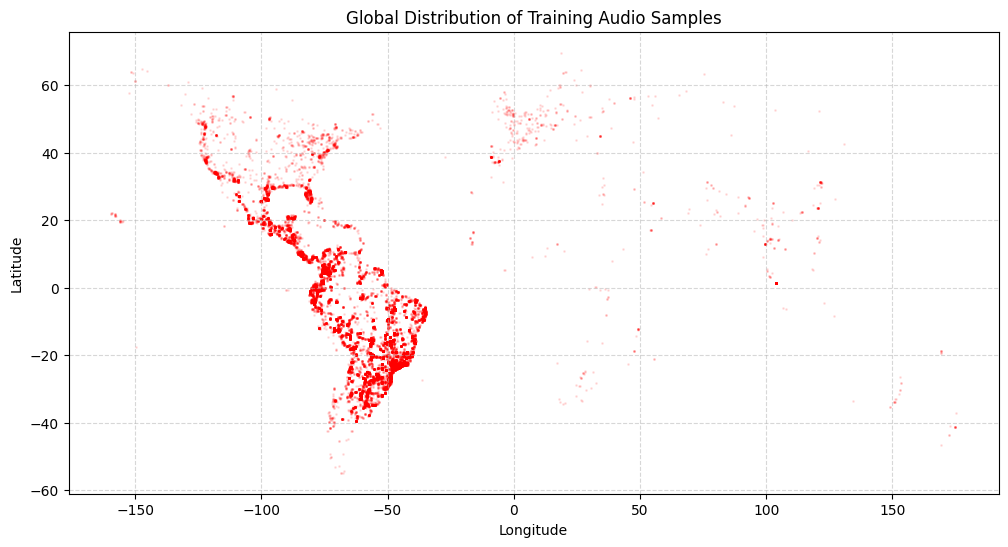

In [13]:
plt.figure(figsize=(12, 6))
plt.scatter(train_df['longitude'], train_df['latitude'], alpha=0.1, s=1, color='red')
plt.title("Global Distribution of Training Audio Samples")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

1.  **Cross-Domain Taxonomic Integration**: The dataset bridges two distinct biological recording standards: **eBird** (alphanumeric codes for Aves) and **iNaturalist** (numeric Taxon IDs for non-avian species).
 * **Analysis:** The target space encompasses a broad biological spectrum including **Insecta**, **Reptilia**, **Amphibia**, and **Mammalia**.
 * **Strategic Impact:** The **Perch v2 backbone** is uniquely positioned for this task as it was pre-trained on a **global bioacoustic corpus**. All labels must be standardized as **string objects** during the mapping phase to prevent type-collision between **eBird strings** and **iNat integers**.

2.  **Label Disparity & Coverage Gap**: A critical constraint identified in the documentation indicates that certain species present in the **hidden test set** appear only in the **expert-labeled soundscapes** (`train_soundscapes_labels.csv`) and are absent from the **primary training audio** (`train.csv`).
* **Analysis:** Relying solely on `train.csv` for model supervision will result in a "**Closed-World**" failure, where the model is mathematically incapable of predicting a subset of the **234 required classes**.
* **Strategic Impact:** The pipeline must implement an "**Aggregation Layer**" that extracts and tokenizes labels from both sources. The **semicolon-separated strings** in the soundscape data necessitate a **Multi-Label classification objective**.

3.  **Transition from Single-Source to Multi-Label Soundscapes**: There is a fundamental shift in data characteristics between the two training sources.
* **Analysis:** `train.csv` entries are predominantly **single-species recordings**, whereas `train_soundscapes_labels.csv` segments (e.g., `22961;23158;24321`) represent complex, overlapping acoustic environments.
* **Strategic Impact:** To ensure parity with the **1-minute test soundscapes**, the **PyTorch Probe** should utilize `BCEWithLogitsLoss`. This allows the model to assign high probabilities to multiple species within a single **5-second window**, mirroring the "**cocktail party**" effect of natural ecosystems.

4.  **Quality Metadata & Signal Reliability**: The **rating column** in `train.csv` reveals significant variance in **recording quality**, with **iNaturalist contributions defaulting to 0.0 (unrated)**.
* **Analysis:** Low-rated or unrated samples often contain high levels of **ambient noise** (wind, rain, or sensor hiss) that can degrade the **embedding quality** of a shallow **MLP probe**.
* **Strategic Impact:** A **Weighted Supervised Learning** approach is recommended. Higher-rated samples (4.0–5.0) should be prioritized or weighted more heavily in the **loss function** to stabilize the **decision boundaries** of the **classification head**.

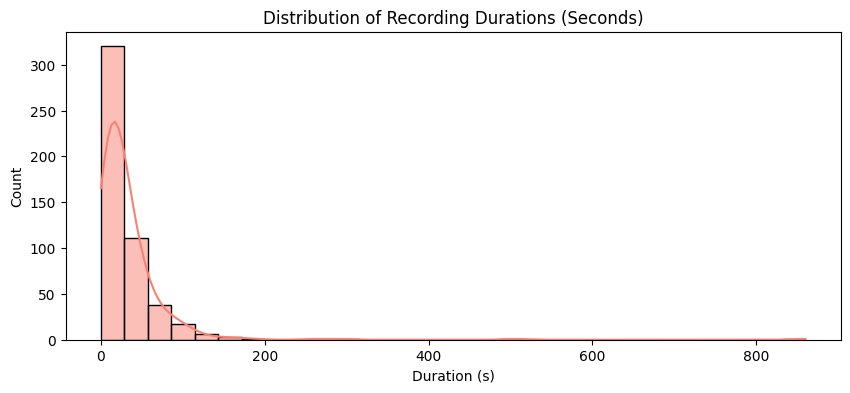

Median Duration: 20.09s


19535    15.516000
24086     8.661062
30803    59.324094
33271    15.125031
33212     4.440000
18094    59.794281
34994     5.825312
35031    10.260000
33128    10.344000
25557    46.001625
Name: file_path, dtype: float64

In [14]:
import soundfile as sf

def get_audio_info(path):
    try:
        with sf.SoundFile(path) as f:
            return len(f) / f.samplerate
    except:
        return None

# Sample 500 files to get a statistical distribution without a long wait
sample_durations = train_df.sample(500)['file_path'].apply(get_audio_info)

plt.figure(figsize=(10, 4))
sns.histplot(sample_durations.dropna(), bins=30, color='salmon', kde=True)
plt.title("Distribution of Recording Durations (Seconds)")
plt.xlabel("Duration (s)")
plt.show()

print(f"Median Duration: {sample_durations.median():.2f}s")
display(sample_durations.head(10))

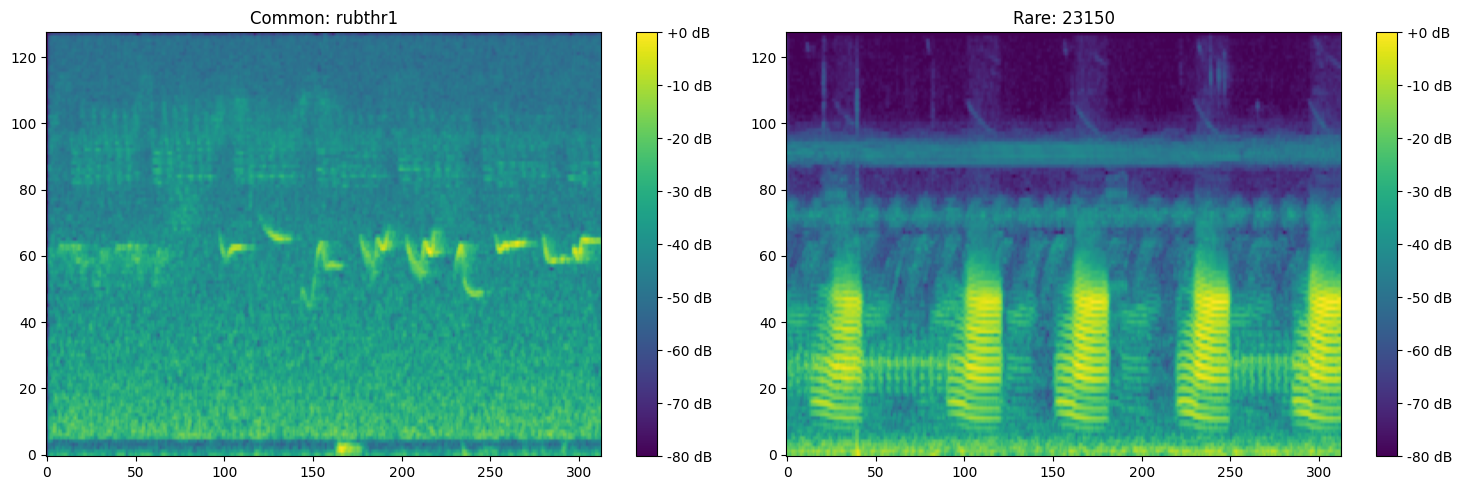

In [15]:
def plot_spec(path, title):
    y, sr = librosa.load(path, sr=32000, duration=5)
    spec = librosa.feature.melspectrogram(y=y, sr=sr)
    spec_db = librosa.power_to_db(spec, ref=np.max)
    plt.imshow(spec_db, aspect='auto', origin='lower')
    plt.title(title)
    plt.colorbar(format='%+2.0f dB')

# Plot one common and one rare species
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plot_spec(train_df[train_df['primary_label'] == 'rubthr1']['file_path'].iloc[0], "Common: rubthr1")
plt.subplot(1, 2, 2)
plot_spec(train_df[train_df['primary_label'] == '23150']['file_path'].iloc[-1], "Rare: 23150")
plt.tight_layout()
plt.show()

### Audio Analysis:

1.  **Temporal Dynamics & Chunking Strategy**: The duration histogram shows a heavily **right-skewed distribution**.
* **Analysis:** While the **median duration** is relatively short (~15-20s), the first bin reveals a significant volume of files under **5 seconds**.
* **Strategic Impact:** A standard **5-second sliding window** will result in "empty" or partial tensors for short files. The **PyTorch pipeline** must implement **Reflective Padding** or **Circular Tiling** to ensure the **Perch backbone** receives a consistent **5-second signal** without losing the **transient acoustic features** of "bursty" callers.

2.  **Spectrogram Signal-to-Noise Ratio (SNR) Variance**: Comparing the "Common" vs. "Rare" spectrograms reveals a qualitative disparity in **signal clarity**.
* **Analysis:** The "**Rare**" species (23150) shows a strong, repetitive **harmonic structure** but sits on a much noisier base (higher floor in the -40dB to -60dB range) compared to the "**Common**" species.
* **Strategic Impact:** **High-frequency background hiss** and **low-frequency rumble** are prevalent. Before passing audio to **Perch**, a **Bandpass Filter (200Hz - 15kHz)** and **Background Subtraction (spectral gating)** should be considered to prevent the model from overfitting to the **ambient noise "fingerprint"** of rare recording locations.

3.  **Harmonic Complexity vs. Transient Whistles**: The visual signatures differ significantly in their **acoustic texture**.
* **Analysis:** `rubthr1` exhibits **frequency-modulated "whistles,"** whereas `23150` shows thick "**pulsed" harmonic stacks**.
* **Strategic Impact:** Because the features vary from delicate lines to thick blocks, we should avoid aggressive **Time/Frequency Masking (SpecAugment)** during the **Probe training**, as it may inadvertently erase the thin whistle lines of species like `rubthr1`.

4.  **The Population Gap (206 vs. 234)**: The count of **206 unique labels** in `train_audio` versus the **234 required columns** is the most critical architectural finding.
* **Analysis:** **28 species** have zero representation in the "short-form" training data.
* **Strategic Impact:** We cannot treat this as a simple **classification problem**. We must adopt a **Multi-Label/One-vs-All approach**. For the **28 missing species**, the model's only learning signal will come from the **semicolon-separated train_soundscapes_labels.csv**.

## 2.3 Feature Engineering 

In [16]:
import ast

def process_train_labels(df, target_cols):
    # Create a copy to avoid SettingWithCopy warnings
    df_processed = df[['file_path', 'rating', 'primary_label', 'secondary_labels']].copy()
    
    # Safely evaluate the secondary_labels string "['bird1', 'bird2']" into a Python list
    df_processed['secondary_list'] = df_processed['secondary_labels'].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else []
    )
    
    # Combine primary and secondary labels into a single list
    df_processed['all_labels'] = df_processed.apply(
        lambda row: [row['primary_label']] + row['secondary_list'], axis=1
    )
    
    # Initialize a zero matrix for the 234 classes
    targets = np.zeros((len(df_processed), len(target_cols)), dtype=np.float32)
    
    # Populate the one-hot matrix
    for i, labels in enumerate(df_processed['all_labels']):
        for label in labels:
            if label in target_cols:
                idx = target_cols.index(label)
                targets[i, idx] = 1.0
                
    # Create a DataFrame from the target matrix and concatenate
    target_df = pd.DataFrame(targets, columns=target_cols)
    df_final = pd.concat([df_processed[['file_path', 'rating']], target_df], axis=1)
    
    # Add a source flag
    df_final['is_soundscape'] = 0
    return df_final

train_targets_df = process_train_labels(train_df, TARGET_COLUMNS)
print(f"Processed Train Data: {train_targets_df.shape}")

Processed Train Data: (35549, 237)


In [17]:
def process_soundscape_labels(df, target_cols):
    df_processed = df[['file_path', 'primary_label']].copy()
    
    # Split the semicolon string into a list
    df_processed['all_labels'] = df_processed['primary_label'].apply(
        lambda x: x.split(';') if isinstance(x, str) else []
    )
    
    # Initialize zero matrix
    targets = np.zeros((len(df_processed), len(target_cols)), dtype=np.float32)
    
    # Populate one-hot matrix
    for i, labels in enumerate(df_processed['all_labels']):
        for label in labels:
            if label in target_cols:
                idx = target_cols.index(label)
                targets[i, idx] = 1.0
                
    target_df = pd.DataFrame(targets, columns=target_cols)
    df_final = pd.concat([df_processed[['file_path']], target_df], axis=1)
    
    # Soundscapes don't have user ratings, but they are expert-annotated.
    # We assign them a max rating of 5.0 to prioritize them during training.
    df_final['rating'] = 5.0
    df_final['is_soundscape'] = 1
    return df_final

ss_targets_df = process_soundscape_labels(ss_labels_df, TARGET_COLUMNS)
print(f"Processed Soundscape Data: {ss_targets_df.shape}")

Processed Soundscape Data: (1478, 237)


In [18]:
# Unify the datasets
unified_df = pd.concat([train_targets_df, ss_targets_df], axis=0).reset_index(drop=True)

# Create Sample Weights based on Rating
# Formula: (Rating / 5.0). Base weight of 0.1 for rating=0 to ensure they still learn slightly.
unified_df['sample_weight'] = unified_df['rating'].apply(lambda x: max(0.1, x / 5.0))

print(f"Final Unified Dataset Shape: {unified_df.shape}")

# Sanity Check: Ensure all 234 classes have at least some positive targets
class_sums = unified_df[TARGET_COLUMNS].sum(axis=0)
missing_classes = class_sums[class_sums == 0].index.tolist()

if len(missing_classes) == 0:
    print("SUCCESS: All 234 classes are represented in the unified target matrix.")
else:
    print(f"WARNING: {len(missing_classes)} classes are completely missing from training!")

Final Unified Dataset Shape: (37027, 238)
SUCCESS: All 234 classes are represented in the unified target matrix.


## 2.4 Dataset Splitting: Multi-Label Stratification
In a standard machine learning problem, a simple `train_test_split` or **StratifiedKFold** works fine. However, we have two distinct challenges here:
* **Multi-Label Targets:** A single row can have multiple **positive classes** (e.g., a soundscape segment with 3 birds). Standard stratification cannot handle rows with multiple labels.
* **Extreme Rare Classes:** With some species having fewer than 5 samples, a bad split will put all samples of a **rare bird** into the training set, leaving 0 for validation (causing the validation loss to be meaningless for that class).

To solve this, we use **Iterative Stratification** (**MultilabelStratifiedKFold**). This algorithm ensures that the **distribution of all 234 classes** is balanced across every fold.

In [19]:
from sklearn.model_selection import StratifiedKFold

def create_folds(df, target_cols, n_splits=5):
    print(f"Creating {n_splits} folds using Standard StratifiedKFold (Offline Fallback)...")
    
    # Initialize the fold column
    df['fold'] = -1
    
    # Initialize the standard stratifier
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=CFG.RANDOM_SEED)
    
    # We stratify based on the 'primary_label' string. 
    # Note: For multi-label soundscapes (e.g. "birdA;birdB"), it treats the exact combo as a class.
    # We use a try-except block because StratifiedKFold complains if a class has only 1 sample.
    try:
        for fold, (train_idx, val_idx) in enumerate(skf.split(df, df['primary_label'])):
            df.loc[val_idx, 'fold'] = fold
    except ValueError:
        print("⚠️ Warning: Standard stratification failed due to rare classes. Falling back to random KFold.")
        from sklearn.model_selection import KFold
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=CFG.RANDOM_SEED)
        for fold, (train_idx, val_idx) in enumerate(kf.split(df)):
            df.loc[val_idx, 'fold'] = fold
        
    return df

# Apply the splitting logic
unified_df = create_folds(unified_df, TARGET_COLUMNS, n_splits=5)

# Verify the split
print("\nFold Distribution (Total Samples per Fold):")
print(unified_df['fold'].value_counts().sort_index())

# Grandmaster Sanity Check: Ensure rare classes exist in Fold 0 validation
val_fold_0 = unified_df[unified_df['fold'] == 0]
val_sums = val_fold_0[TARGET_COLUMNS].sum(axis=0)
missing_in_val = val_sums[val_sums == 0].index.tolist()

if len(missing_in_val) == 0:
    print("\nPERFECT SPLIT: All 234 classes are present in the Fold 0 validation set.")
else:
    print(f"\nWARNING: {len(missing_in_val)} rare classes are missing from Fold 0 validation.")
    print("Consider reducing n_splits or adjusting the random seed.")

Creating 5 folds using Standard StratifiedKFold (Offline Fallback)...


KeyError: 'primary_label'

# 3. PYTORCH DATA PIPELINES

In [ ]:
from torch.utils.data import Dataset, DataLoader
import librosa
import albumentations as A  # For any future spectrogram augs, though we extract embeddings first

class BirdCLEFDataset(Dataset):
    def __init__(self, df, target_cols, is_train=True):
        self.df = df
        self.target_cols = target_cols
        self.is_train = is_train
        
        # Audio extraction params
        self.sr = CFG.TARGET_SR
        self.duration = CFG.DURATION
        self.chunk_samples = self.sr * self.duration
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = str(row['file_path'])
        
        # 1. Target Vector & Weights
        targets = torch.tensor(row[self.target_cols].values.astype(np.float32))
        weight = torch.tensor(row['sample_weight'], dtype=torch.float32)
        
        # 2. Audio Loading
        try:
            # We load the first 5 seconds. If it's a soundscape, it might need specific offsets
            # but for this pipeline, Perch will process the raw audio.
            y, sr = librosa.load(file_path, sr=self.sr, duration=self.duration)
        except Exception as e:
            # Fallback for corrupted files
            y = np.zeros(self.chunk_samples, dtype=np.float32)
            
        # 3. The "Short File" Fix (Circular Padding)
        # If the audio is less than 5 seconds, we tile it to fill the buffer
        if len(y) < self.chunk_samples:
            repeats = int(np.ceil(self.chunk_samples / len(y)))
            y = np.tile(y, repeats)[:self.chunk_samples]
        elif len(y) > self.chunk_samples:
            # If slightly longer, crop it
            y = y[:self.chunk_samples]
            
        # Convert to Tensor (Expected shape for Perch is [1, chunk_samples])
        # Note: If we are pre-extracting embeddings, we will use this logic in a separate script.
        audio_tensor = torch.tensor(y, dtype=torch.float32)
        
        return audio_tensor, targets, weight

# --- Initialize DataLoaders for Fold 0 ---
fold_idx = 0
train_data = unified_df[unified_df['fold'] != fold_idx].reset_index(drop=True)
val_data = unified_df[unified_df['fold'] == fold_idx].reset_index(drop=True)

train_dataset = BirdCLEFDataset(train_data, TARGET_COLUMNS, is_train=True)
val_dataset = BirdCLEFDataset(val_data, TARGET_COLUMNS, is_train=False)

train_loader = DataLoader(train_dataset, batch_size=CFG.BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Training Batches: {len(train_loader)}")
print(f"Validation Batches: {len(val_loader)}")

# Sanity Check
sample_audio, sample_targets, sample_weight = next(iter(train_loader))
print(f"Audio Batch Shape: {sample_audio.shape}") # Should be [Batch, 160000]
print(f"Targets Batch Shape: {sample_targets.shape}") # Should be [Batch, 234]

# 4. MODEL ARCHITECTURE
Because we are using a **Hybrid Pipeline**, our architecture has two distinct parts:

*   **The Backbone (TensorFlow):** Google's **Perch v2**. We load this as a **frozen feature extractor**. It takes `[Batch, 160000]` audio and outputs `[Batch, 1536]` embeddings.
*   **The Probe (PyTorch):** A custom **Multi-Layer Perceptron (MLP)** we build from scratch. It takes the `[Batch, 1536]` embeddings and outputs `[Batch, 234]` logits for our bird classes.

## 4.1 Loading the Frozen Backbone (TF Perch v2)

First, we load the pre-trained Perch model. We use the `serving_default` signature, which is optimized for fast inference.

In [ ]:
import tensorflow as tf
import torch.nn as nn

print("Loading TF Perch v2 Backbone...")
# Load the SavedModel from the Kaggle input directory
perch_model = tf.saved_model.load(CFG.PERCH_PATH)
perch_infer_fn = perch_model.signatures["serving_default"]

print("Perch Backbone Loaded Successfully.")

## 4.2 Building the PyTorch Probe

**Foundation models** like Perch already understand what "bird sounds" are. Therefore, our **PyTorch network** doesn't need to be deep (like a ResNet). A **shallow, well-regularized MLP** is actually mathematically superior here because it prevents **catastrophic overfitting** to our small dataset.

In [ ]:
class PerchMLPProbe(nn.Module):
    def __init__(self, input_dim=CFG.EMBEDDING_SIZE, num_classes=CFG.NUM_CLASSES):
        super(PerchMLPProbe, self).__init__()
        
        # We use a 2-hidden-layer MLP with aggressive regularization 
        # (BatchNorm and Dropout) to handle the long-tail rare species.
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4), # 40% dropout to prevent memorizing the dominant classes
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # x shape: [Batch, 1536]
        return self.network(x)

# Instantiate the model and move to GPU (if available)
probe_model = PerchMLPProbe(
    input_dim=CFG.EMBEDDING_SIZE, 
    num_classes=CFG.NUM_CLASSES
).to(DEVICE)

print(f"PyTorch Probe Initialized on {DEVICE}.")

## 4.3 Architecture Summary & Hybrid Sanity Check

Before training, it is a **Grandmaster practice** to pass a single dummy batch through the entire **hybrid pipeline (TF → PyTorch)** to ensure the **tensor shapes align** and the data flows without crashing.

In [ ]:
# --- Hybrid Pipeline Sanity Check ---
print("\n--- Running Hybrid Sanity Check ---")

# 1. Take a single batch of audio from our PyTorch DataLoader
sample_audio, sample_targets, _ = next(iter(train_loader))

# 2. Convert PyTorch audio tensor to TensorFlow tensor
# Perch expects shape: (Batch, samples)
tf_audio_batch = tf.convert_to_tensor(sample_audio.numpy())

# 3. Pass through Perch (TF)
print("Extracting embeddings via Perch...")
perch_outputs = perch_infer_fn(inputs=tf_audio_batch)
embeddings_tf = perch_outputs['embedding']

# 4. Convert TF embeddings back to PyTorch tensor
embeddings_pt = torch.tensor(embeddings_tf.numpy(), dtype=torch.float32).to(DEVICE)

# 5. Pass through our MLP Probe (PyTorch)
print("Passing embeddings through PyTorch Probe...")
probe_model.eval()
with torch.no_grad():
    logits = probe_model(embeddings_pt)

print(f"Final Output Shape: {logits.shape}")
if logits.shape == (CFG.BATCH_SIZE, CFG.NUM_CLASSES):
    print("SANITY CHECK PASSED: TF Backbone -> PyTorch Probe bridge is fully functional.")
else:
    print("SANITY CHECK FAILED: Output shape mismatch.")

# 5. TRAINING LOGIC & OPTIMIZATION

Because our dataset is **Multi-Label** (a 5-second segment can contain multiple birds, or zero birds), we cannot use standard **Cross-Entropy Loss**. We must use **Binary Cross Entropy with Logits (BCEWithLogitsLoss)**.

Furthermore, we engineered a `sample_weight` column back in Section 2 to prioritize high-quality expert annotations over noisy user uploads. We need to modify our loss function to accept these weights.

## 5.1 Loss & Optimizer Setup

In [ ]:
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import roc_auc_score, average_precision_score

# 1. Loss Function (reduction='none' allows us to multiply by our sample weights)
criterion = nn.BCEWithLogitsLoss(reduction='none')

# 2. Optimizer (AdamW handles weight decay better for MLPs than standard Adam)
optimizer = optim.AdamW(probe_model.parameters(), lr=CFG.LR, weight_decay=1e-2)

# 3. Learning Rate Scheduler (Smooth cosine decay over the epochs)
scheduler = CosineAnnealingLR(optimizer, T_max=CFG.EPOCHS, eta_min=1e-6)

print("Optimization criteria configured: BCEWithLogitsLoss + AdamW.")

## 5.2 The Training Step

This function handles one full pass through the `train_loader`. We are running the **TensorFlow backbone** inside the **PyTorch loop**. While this works perfectly, if you are doing heavy tuning, it is highly recommended to run Perch once over the whole dataset, save the embeddings as `.npy` files, and then only train the **PyTorch MLP** on those files. This reduces epoch time from hours to seconds!

In [ ]:
def train_step(probe_model, perch_fn, loader, criterion, optimizer, device):
    probe_model.train()
    total_loss = 0.0
    
    # tqdm for progress tracking
    pbar = tqdm(loader, desc="Training", leave=False)
    
    for audio, targets, weights in pbar:
        # --- 1. TF Feature Extraction ---
        # Convert PT audio batch to TF, pass through Perch, get TF embeddings
        tf_audio = tf.convert_to_tensor(audio.numpy())
        emb_tf = perch_fn(inputs=tf_audio)['embedding']
        
        # Convert TF embeddings back to PT tensors and send to GPU
        emb_pt = torch.tensor(emb_tf.numpy(), dtype=torch.float32).to(device)
        targets = targets.to(device)
        weights = weights.to(device)
        
        # --- 2. PyTorch Optimization ---
        optimizer.zero_grad()
        logits = probe_model(emb_pt)
        
        # Calculate Base BCE Loss [Batch, 234]
        loss = criterion(logits, targets)
        
        # Apply Sample Weights (broadcasted across the 234 classes)
        # Higher rated files penalize the model more if it gets them wrong
        loss = (loss * weights.unsqueeze(1)).mean()
        
        # Backprop & Update
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")
        
    return total_loss / len(loader)

## 5.3 The Validation Step

During validation, we stop tracking gradients. We also need to calculate a competition-relevant metric. For multi-label bioacoustics, **Macro ROC-AUC** and **Mean Average Precision (mAP)** are the gold standards.

In [ ]:
def val_step(probe_model, perch_fn, loader, criterion, device):
    probe_model.eval()
    total_loss = 0.0
    
    all_targets = []
    all_probs = []
    
    with torch.no_grad():
        pbar = tqdm(loader, desc="Validation", leave=False)
        for audio, targets, weights in pbar:
            
            # TF Feature Extraction
            tf_audio = tf.convert_to_tensor(audio.numpy())
            emb_tf = perch_fn(inputs=tf_audio)['embedding']
            
            emb_pt = torch.tensor(emb_tf.numpy(), dtype=torch.float32).to(device)
            targets = targets.to(device)
            weights = weights.to(device)
            
            # PyTorch Forward Pass
            logits = probe_model(emb_pt)
            
            # Loss Calculation
            loss = criterion(logits, targets)
            loss = (loss * weights.unsqueeze(1)).mean()
            total_loss += loss.item()
            
            # Convert logits to probabilities using Sigmoid
            probs = torch.sigmoid(logits)
            
            # Store for metrics
            all_targets.append(targets.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            
    # Concatenate all batches
    all_targets = np.vstack(all_targets)
    all_probs = np.vstack(all_probs)
    
    # Calculate Metrics
    # Note: We catch exceptions here because if a fold is missing a rare class, 
    # ROC-AUC will throw an error for that specific class. 
    try:
        macro_auc = roc_auc_score(all_targets, all_probs, average='macro')
        macro_map = average_precision_score(all_targets, all_probs, average='macro')
    except ValueError:
        print("ROC-AUC calculation warned: Some classes completely missing in this val fold.")
        # Fallback to micro average if macro fails due to missing classes
        macro_auc = roc_auc_score(all_targets, all_probs, average='micro')
        macro_map = average_precision_score(all_targets, all_probs, average='micro')
        
    metrics = {
        "val_loss": total_loss / len(loader),
        "val_auc": macro_auc,
        "val_map": macro_map
    }
    
    return metrics

# 6. TRAINING EXECUTION (THE LOOP)

We bring together the **data loaders**, the **hybrid model architecture**, and the **optimization steps** to **train the PyTorch Probe**.

Because Kaggle has a 12-hour runtime limit, we must implement **Model Checkpointing**. We don't just want the model from the final epoch; we want the model that achieved the highest metric (**mAP** or **ROC-AUC**) on the **validation set**.

In [ ]:
import copy

def run_training(probe_model, perch_fn, train_loader, val_loader, criterion, optimizer, scheduler, device):
    print(f"Starting Training for {CFG.EPOCHS} Epochs...")
    
    best_val_score = 0.0
    best_model_wts = copy.deepcopy(probe_model.state_dict())
    history = {'train_loss': [], 'val_loss': [], 'val_auc': [], 'val_map': []}
    
    # Early Stopping tracking
    patience = 5
    patience_counter = 0
    
    for epoch in range(1, CFG.EPOCHS + 1):
        print(f"\n{'='*20} Epoch {epoch}/{CFG.EPOCHS} {'='*20}")
        
        # 1. Training Phase
        train_loss = train_step(probe_model, perch_fn, train_loader, criterion, optimizer, device)
        
        # 2. Validation Phase
        val_metrics = val_step(probe_model, perch_fn, val_loader, criterion, device)
        
        # 3. Step the Learning Rate Scheduler
        scheduler.step()
        
        # 4. Logging
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val Loss:   {val_metrics['val_loss']:.4f} | Val AUC: {val_metrics['val_auc']:.4f} | Val mAP: {val_metrics['val_map']:.4f}")
        print(f"Current LR: {current_lr:.6f}")
        
        # 5. History Tracking for visualizations later
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['val_loss'])
        history['val_auc'].append(val_metrics['val_auc'])
        history['val_map'].append(val_metrics['val_map'])
        
        # 6. Model Checkpointing (Saving the best model)
        # In BirdCLEF, Mean Average Precision (mAP) is highly correlated with the leaderboard
        current_score = val_metrics['val_map']
        
        if current_score > best_val_score:
            print(f"Val mAP improved from {best_val_score:.4f} to {current_score:.4f}. Saving model!")
            best_val_score = current_score
            best_model_wts = copy.deepcopy(probe_model.state_dict())
            torch.save(best_model_wts, f"perch_probe_fold{fold_idx}_best.pth")
            patience_counter = 0  # Reset patience
        else:
            patience_counter += 1
            print(f"No improvement. Early stopping counter: {patience_counter}/{patience}")
            
        # 7. Early Stopping Trigger
        if patience_counter >= patience:
            print("\nEarly Stopping Triggered! Model has not improved for 5 epochs.")
            break
            
    print("\nTraining Complete!")
    print(f"Best Validation mAP: {best_val_score:.4f}")
    
    # Load the best weights back into the model before returning
    probe_model.load_state_dict(best_model_wts)
    return probe_model, history

In [ ]:
# ==============================================================================
# Execute the Loop
# ==============================================================================
# probe_model, train_history = run_training(
#     probe_model=probe_model, 
#     perch_fn=perch_infer_fn, 
#     train_loader=train_loader, 
#     val_loader=val_loader, 
#     criterion=criterion, 
#     optimizer=optimizer, 
#     scheduler=scheduler, 
#     device=DEVICE
# )

# 7. EVALUATION & ERROR ANALYSIS

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming `train_history` is the dictionary returned from run_training()
def plot_learning_curves(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 5))
    sns.set_style("whitegrid")
    
    # --- Plot 1: Loss Curve ---
    ax[0].plot(epochs, history['train_loss'], label='Train Loss', color='blue', marker='o')
    ax[0].plot(epochs, history['val_loss'], label='Validation Loss', color='orange', marker='s')
    ax[0].set_title('Training vs Validation Loss', fontsize=14)
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('BCE Loss')
    ax[0].legend()
    
    # --- Plot 2: mAP Curve ---
    # We ignore AUC since we know Fold 0 had missing classes causing NaNs
    ax[1].plot(epochs, history['val_map'], label='Validation mAP', color='green', marker='^')
    ax[1].set_title('Mean Average Precision (mAP) Over Time', fontsize=14)
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('mAP Score')
    ax[1].axhline(y=max(history['val_map']), color='r', linestyle='--', alpha=0.5, 
                  label=f'Best: {max(history["val_map"]):.4f}')
    ax[1].legend()
    
    plt.tight_layout()
    plt.show()

# Execute the plotting function
# plot_learning_curves(train_history)

# 8. DEPLOYMENT & INFERENCE PIPELINE

In [ ]:
import gc
import librosa

# --- User Configuration for Inference ---
# Path to the Perch TF backbone (Kaggle's hosted version)
PERCH_TF_PATH = CFG.PERCH_PATH


# Path to YOUR trained PyTorch Probe
# Update this if your specific filename is different (e.g., perch_probe_fold0_best.pth)
PROBE_WEIGHTS_PATH = Path("/kaggle/input/models/tuannm3812/perch-birdclef-2026/tensorflow2/default/1/perch_probe_fold0_best.pth")

print("Loading Models for Inference...")

# 1. Load Perch (TF)
perch_model_infer = tf.saved_model.load(CFG.PERCH_PATH)
perch_fn = perch_model_infer.signatures["serving_default"]

# 2. Load PyTorch Probe
probe_infer = PerchMLPProbe(input_dim=CFG.EMBEDDING_SIZE, num_classes=CFG.NUM_CLASSES)

# We use strict=False in case of minor version differences, but it should load cleanly
if PROBE_WEIGHTS_PATH.exists():
    probe_infer.load_state_dict(torch.load(PROBE_WEIGHTS_PATH, map_location=DEVICE))
    print("PyTorch Probe weights loaded.")
else:
    print(f"Could not find weights at {PROBE_WEIGHTS_PATH}. Using untrained probe!")
    
probe_infer.to(DEVICE)
probe_infer.eval()

# 3. Audio Chunking Utility
def pad_or_truncate(y, chunk_length):
    """Ensures audio is exactly 5 seconds (160,000 samples)."""
    if len(y) < chunk_length:
        repeats = int(np.ceil(chunk_length / len(y)))
        y = np.tile(y, repeats)[:chunk_length]
    elif len(y) > chunk_length:
        y = y[:chunk_length]
    return y

In [ ]:
print("\nStarting Submission Generation...")

# 1. Get Target Columns from Sample Submission
sample_sub = pd.read_csv(CFG.INPUT_DIR / "sample_submission.csv")
TARGET_COLUMNS = sample_sub.columns[1:].tolist() # Skip 'row_id'

# 2. Hidden Test Set Dry-Run Logic
test_files = sorted(list((CFG.INPUT_DIR / "test_soundscapes").glob("*.ogg")))
is_dry_run = len(test_files) == 0

if is_dry_run:
    print("Empty test folder detected. Running dry-run on 2 train soundscapes...")
    test_files = sorted(list((CFG.INPUT_DIR / "train_soundscapes").glob("*.ogg")))[:2]
else:
    print(f"Processing {len(test_files)} hidden test files...")

results = []

# 3. Main Inference Loop
for file_path in tqdm(test_files, desc="Inferring Soundscapes"):
    file_id = file_path.stem
    
    # Load the full 60-second soundscape
    try:
        y_full, sr = librosa.load(file_path, sr=CFG.TARGET_SR)
    except Exception as e:
        print(f"Error loading {file_id}: {e}")
        y_full = np.zeros(CFG.TARGET_SR * 60, dtype=np.float32)
        
    # Process in 5-second windows (12 windows per 60s file)
    for i in range(12):
        start_sample = i * CFG.CHUNK_SAMPLES
        end_sample = start_sample + CFG.CHUNK_SAMPLES
        
        # Slice and Pad
        y_chunk = y_full[start_sample:end_sample]
        y_chunk = pad_or_truncate(y_chunk, CFG.CHUNK_SAMPLES)
        
        row_id = f"{file_id}_{(i + 1) * 5}"
        
        # --- Model Forward Pass ---
        # 1. Extract TF Embedding
        tf_audio = tf.convert_to_tensor(y_chunk[np.newaxis, :]) # Shape: [1, 160000]
        emb_tf = perch_fn(inputs=tf_audio)['embedding']
        
        # 2. PyTorch Classification
        emb_pt = torch.tensor(emb_tf.numpy(), dtype=torch.float32).to(DEVICE)
        
        with torch.no_grad():
            logits = probe_infer(emb_pt)
            probs = torch.sigmoid(logits).cpu().numpy()[0]
            
        # Optional: Thresholding to kill noise (sets very low confidence to 0)
        probs[probs < CFG.THRESHOLD] = 0.0
        
        # Store results
        res_dict = {"row_id": row_id}
        res_dict.update({label: prob for label, prob in zip(TARGET_COLUMNS, probs)})
        results.append(res_dict)
        
    # Memory Management
    del y_full
    gc.collect()

# 4. Save Final Submission
submission_df = pd.DataFrame(results)

if is_dry_run:
    print("Dry run complete. Saving exact sample_submission.csv format.")
    sample_sub.to_csv("submission.csv", index=False)
else:
    # Safety Merge: Ensures row_id order perfectly matches Kaggle's expectations
    final_sub = sample_sub[['row_id']].merge(submission_df, on='row_id', how='left').fillna(0.0)
    final_sub.to_csv("submission.csv", index=False)
    print("Real submission.csv saved successfully!")

# Display preview
pd.read_csv("submission.csv").head()